# Surrogate model design (RANDOM split) — pooling x architecture sweep

Same as `surrogate_model_design.ipynb`, but train / val / test are a **random** split (not by
sequence-identity cluster). Use this when the design goal is **local re-design** — small edits to a known
scaffold — where train and test legitimately share families, so random split estimates the relevant
*in-distribution* performance. (For out-of-distribution generalization, use the cluster-split notebook.)

Readouts: 4 poolings (mean / min / max / std) x {MLP, CNN}; metrics on **train and validation** only
(test held out). Models cache to `trained_models/`, keyed by a random-split fingerprint so they don't
collide with the cluster-split cache.

## 0. Setup, data, per-residue ESM-2 embeddings (cached)

In [1]:
import csv, os, time
import numpy as np, torch, torch.nn as nn, esm
import arcadia_pycolor as apc
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
    apc.mpl.setup()   # Arcadia (apc) styling: fonts, spines, color cycle
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32)
grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EXM=np.array([float(r["ex_max"]) for r in rows]); EMM=np.array([float(r["em_max"]) for r in rows])
# --- RANDOM train/val/test split (goal: local re-design, in-distribution) ---
SPLIT_SEED = 0
_rng = np.random.default_rng(SPLIT_SEED)
_perm = _rng.permutation(N)
_nval = int(round(0.15 * N)); _ntest = int(round(0.15 * N))
sur = np.array(["train"] * N)            # dtype <U5 -> stable cache fingerprint
sur[_perm[:_ntest]] = "test"
sur[_perm[_ntest:_ntest + _nval]] = "val"
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
m={b:np.where(sur==b)[0] for b in("train","val","test")}
print("device",dev,"| surrogate",{b:len(v) for b,v in m.items()})

device mps | surrogate {'train': 317, 'val': 68, 'test': 68}


In [2]:
# per-residue layer-33 embeddings -> cache fp16 (N,Lmax,1280) + lengths
RP=os.path.join(TD,"esm_residue_fp16.npy"); LP=os.path.join(TD,"esm_residue_len.npy")
if os.path.exists(RP) and np.load(LP).shape[0]==N:
    H=np.load(RP); Ls=np.load(LP); print("loaded per-residue cache", H.shape)
else:
    model,alphabet=esm.pretrained.esm2_t33_650M_UR50D(); model=model.eval().to(dev)
    for p in model.parameters(): p.requires_grad_(False)
    bc=alphabet.get_batch_converter(); Lmax=max(len(s) for s in seqs)
    H=np.zeros((N,Lmax,1280),dtype=np.float16); Ls=np.zeros(N,dtype=np.int64); t=time.time()
    with torch.no_grad():
        for i in range(0,N,16):
            ch=seqs[i:i+16]; _,_,tk=bc([(f"s{j}",s) for j,s in enumerate(ch)]); tk=tk.to(dev)
            reps=model(tk,repr_layers=[33])["representations"][33]
            for j,s in enumerate(ch):
                n=len(s); H[i+j,:n]=reps[j,1:1+n].float().cpu().numpy().astype(np.float16); Ls[i+j]=n
    np.save(RP,H); np.save(LP,Ls); print(f"cached per-residue {H.shape} in {time.time()-t:.0f}s")
Lmax=H.shape[1]; Ht=torch.tensor(H); ar=torch.arange(Lmax)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),torch.tensor(Y[b]).to(dev)

loaded per-residue cache (453, 476, 1280)


## 1. Masked pooling + model (MLP / CNN) + train/eval

`masked_pool` reduces over valid residues (mean/min/max/std). `SpectrumNet` is MLP (pool the raw embeddings)
or CNN (conv over residues, then pool). The pooling is the shared residue-reduction.

In [3]:
def masked_pool(x, mask, kind):                 # x:(B,L,C) mask:(B,L) bool
    mk = mask.unsqueeze(-1)
    cnt = mk.sum(1).clamp(min=1)
    mean = (x*mk).sum(1)/cnt
    if kind=="mean": return mean
    if kind=="max":  return x.masked_fill(~mk, float("-inf")).max(1).values
    if kind=="min":  return x.masked_fill(~mk, float("inf")).min(1).values
    if kind=="std":
        var = (((x-mean.unsqueeze(1))**2)*mk).sum(1)/cnt
        return torch.sqrt(var+1e-8)
    raise ValueError(kind)

class SpectrumNet(nn.Module):
    def __init__(self, pool, use_cnn, d_in=1280, conv_ch=128, k=5, hidden=256, nl=2, drop=0.2, out=2*G):
        super().__init__(); self.pool=pool; self.use_cnn=use_cnn
        if use_cnn:
            self.conv=nn.Sequential(nn.Conv1d(d_in,conv_ch,k,padding=k//2), nn.ReLU(),
                                    nn.Conv1d(conv_ch,conv_ch,k,padding=k//2), nn.ReLU())
            feat=conv_ch
        else:
            self.conv=None; feat=d_in
        L=[nn.Linear(feat,hidden), nn.ReLU()]
        for _ in range(nl-1): L+=[nn.Dropout(drop), nn.Linear(hidden,hidden), nn.ReLU()]
        L+=[nn.Linear(hidden,out)]; self.head=nn.Sequential(*L)
    def forward(self, Hb, mask):
        x = Hb
        if self.use_cnn:
            x = self.conv(x.transpose(1,2)).transpose(1,2)     # (B,L,conv_ch)
        return self.head(masked_pool(x, mask, self.pool))

In [4]:
def exem(S): return grid[np.argmax(S[:,:G],1)], grid[np.argmax(S[:,G:],1)]
def eval_split(net, split):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,yb in batches(m[split]): ps.append(net(Hb,mk).cpu().numpy())
    P=np.concatenate(ps); idx=m[split]; T=Y[idx]; ex,em=exem(P)
    return dict(mse=float(((P-T)**2).mean()),
                ex_mae=float(np.abs(ex-EXM[idx]).mean()),
                em_mae=float(np.abs(em-EMM[idx]).mean()))

def train_eval(pool, use_cnn, epochs, seed=0):
    torch.manual_seed(seed)
    net=SpectrumNet(pool, use_cnn, conv_ch=CONV_CH, k=KSIZE, hidden=HIDDEN, nl=NL, drop=DROP).to(dev)
    opt=torch.optim.Adam(net.parameters(), LR, weight_decay=WD); lf=nn.MSELoss()
    best=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,yb in batches(m["train"], shuffle=True):
            opt.zero_grad(); lf(net(Hb,mk),yb).backward(); opt.step()
        vm=eval_split(net,"val")                       # select by best val
        if best is None or vm["mse"]<best["val"]["mse"]:
            best={"val":vm, "train":eval_split(net,"train"), "ep":ep}
    return best

## 1b. Model caching

Trained models (and learning-curve histories) are cached to `trained_models/` keyed by architecture, pooling,
hyperparameters, epochs, and a data/split fingerprint. Reruns **reload instead of retraining**; change any knob
(or the splits) and the key changes, so it retrains automatically. Set `FORCE_RETRAIN=True` to ignore the cache.

In [5]:
import hashlib, json
MODELS_DIR="trained_models"; os.makedirs(MODELS_DIR, exist_ok=True)
FORCE_RETRAIN=False

def _data_sig():
    h=hashlib.md5(); h.update(sur.tobytes()); h.update(np.asarray(Ls).tobytes())
    h.update(str(Y.shape).encode()); return h.hexdigest()[:8]

def _key(arch,pool,cfg,epochs):
    return (f"{arch}_{pool}_h{cfg['hidden']}_nl{cfg['nl']}_d{cfg['drop']}_wd{cfg['wd']}"
            f"_lr{LR}_cc{CONV_CH}_k{KSIZE}_ep{epochs}_{_data_sig()}")

def get_trained(arch,pool,cfg,epochs):
    """Return (net, metrics, cached?). Best-val checkpoint; cached to trained_models/."""
    key=_key(arch,pool,cfg,epochs); path=os.path.join(MODELS_DIR,key+".pt")
    net=SpectrumNet(pool, arch=="CNN", conv_ch=CONV_CH,k=KSIZE,hidden=cfg["hidden"],nl=cfg["nl"],drop=cfg["drop"]).to(dev)
    if not FORCE_RETRAIN and os.path.exists(path):
        ck=torch.load(path, map_location=dev); net.load_state_dict(ck["state_dict"]); return net, ck["metrics"], True
    opt=torch.optim.Adam(net.parameters(), LR, weight_decay=cfg["wd"]); lf=nn.MSELoss(); best=1e9; bst=None; bep=0
    for ep in range(epochs):
        net.train()
        for Hb,mk,yb in batches(m["train"], shuffle=True):
            opt.zero_grad(); lf(net(Hb,mk),yb).backward(); opt.step()
        v=eval_split(net,"val")["mse"]
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.state_dict().items()}; bep=ep
    net.load_state_dict(bst)
    metrics={"train":eval_split(net,"train"), "val":eval_split(net,"val"), "ep":bep}
    torch.save({"state_dict":{k:v.cpu() for k,v in net.state_dict().items()},
                "metrics":metrics, "config":dict(arch=arch,pool=pool,**cfg), "key":key}, path)
    return net, metrics, False

def get_curve(arch,pool,cfg,epochs):
    """Return (train_hist, val_hist, cached?). Full-epoch history cached as json."""
    key="curve_"+_key(arch,pool,cfg,epochs); path=os.path.join(MODELS_DIR,key+".json")
    if not FORCE_RETRAIN and os.path.exists(path):
        d=json.load(open(path)); return d["train"], d["val"], True
    torch.manual_seed(0)
    net=SpectrumNet(pool, arch=="CNN", conv_ch=CONV_CH,k=KSIZE,hidden=cfg["hidden"],nl=cfg["nl"],drop=cfg["drop"]).to(dev)
    opt=torch.optim.Adam(net.parameters(), LR, weight_decay=cfg["wd"]); lf=nn.MSELoss(); tr=[]; va=[]
    for ep in range(epochs):
        net.train()
        for Hb,mk,yb in batches(m["train"], shuffle=True):
            opt.zero_grad(); lf(net(Hb,mk),yb).backward(); opt.step()
        tr.append(eval_split(net,"train")["mse"]); va.append(eval_split(net,"val")["mse"])
    json.dump({"train":tr,"val":va}, open(path,"w"))
    return tr, va, False

## 2. Sweep: 4 poolings x {MLP, CNN}

Knobs below. Reports train & val MSE and emission-max MAE at each model's best-val epoch.

In [6]:
EPOCHS=150; CONV_CH=128; KSIZE=5; HIDDEN=256; NL=2; DROP=0.2; LR=1e-3; WD=1e-4
POOLS=["mean","min","max","std"]
CFG=dict(hidden=HIDDEN, nl=NL, drop=DROP, wd=WD)

base = Y[m["train"]].mean(0, keepdims=True)
base_val = float(((np.repeat(base,len(m["val"]),0)-Y[m["val"]])**2).mean())
print(f"baseline (mean spectrum) val MSE: {base_val:.5f}\n")

table=[]; t0=time.time()
for arch in ("MLP","CNN"):
    for pool in POOLS:
        net,met,cached=get_trained(arch,pool,CFG,EPOCHS)
        table.append((arch,pool,met))
        print(f"{arch} {pool:4s} {'(cached) ' if cached else '(trained)'} @ep{met['ep']:3d} | "
              f"train MSE {met['train']['mse']:.5f} val MSE {met['val']['mse']:.5f} | "
              f"val emMAE {met['val']['em_mae']:5.1f}")
print(f"\n{len(table)} models ready in {time.time()-t0:.0f}s (cached ones are instant)")

baseline (mean spectrum) val MSE: 0.04926



MLP mean (trained) @ep 80 | train MSE 0.02567 val MSE 0.02967 | val emMAE  25.0


MLP min  (trained) @ep125 | train MSE 0.02449 val MSE 0.02944 | val emMAE  29.3


MLP max  (trained) @ep130 | train MSE 0.02530 val MSE 0.02907 | val emMAE  28.4


MLP std  (trained) @ep149 | train MSE 0.03428 val MSE 0.03231 | val emMAE  26.8


CNN mean (trained) @ep 26 | train MSE 0.02828 val MSE 0.03046 | val emMAE  26.7


CNN min  (trained) @ep 30 | train MSE 0.02208 val MSE 0.03208 | val emMAE  28.5


CNN max  (trained) @ep 93 | train MSE 0.00702 val MSE 0.02689 | val emMAE  22.4


CNN std  (trained) @ep 68 | train MSE 0.01898 val MSE 0.02972 | val emMAE  26.5

8 models ready in 272s (cached ones are instant)


In [7]:
# summary table sorted by val MSE
print(f"{'arch':4s} {'pool':5s} {'train MSE':>9} {'val MSE':>8} {'train emMAE':>12} {'val emMAE':>10}")
for arch,pool,r in sorted(table, key=lambda x:x[2]["val"]["mse"]):
    print(f"{arch:4s} {pool:5s} {r['train']['mse']:9.5f} {r['val']['mse']:8.5f} "
          f"{r['train']['em_mae']:12.1f} {r['val']['em_mae']:10.1f}")
print(f"baseline val MSE {base_val:.5f}")

arch pool  train MSE  val MSE  train emMAE  val emMAE
CNN  max     0.00702  0.02689          7.4       22.4
MLP  max     0.02530  0.02907         19.2       28.4
MLP  min     0.02449  0.02944         17.8       29.3
MLP  mean    0.02567  0.02967         17.8       25.0
CNN  std     0.01898  0.02972         13.3       26.5
CNN  mean    0.02828  0.03046         19.3       26.7
CNN  min     0.02208  0.03208         17.0       28.5
MLP  std     0.03428  0.03231         24.3       26.8
baseline val MSE 0.04926


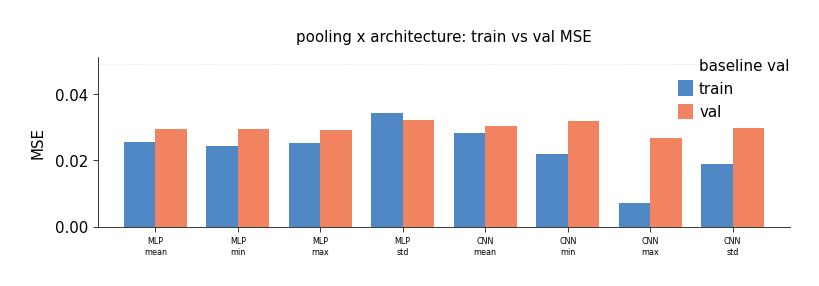

In [8]:
if HAVE_PLT:
    labels=[f"{a}\n{p}" for a,p,_ in table]
    tr=[r["train"]["mse"] for _,_,r in table]; va=[r["val"]["mse"] for _,_,r in table]
    x=np.arange(len(table)); w=0.38
    plt.figure(figsize=(11,3.6))
    plt.bar(x-w/2, tr, w, color=apc.aegean, label="train"); plt.bar(x+w/2, va, w, color=apc.amber, label="val")
    plt.axhline(base_val, color=apc.gray, ls="--", lw=0.8, label="baseline val")
    plt.xticks(x, labels, fontsize=8); plt.ylabel("MSE"); plt.title("pooling x architecture: train vs val MSE")
    plt.legend(); plt.tight_layout(); plt.show()

## 3. Prediction vs ground truth (train & val)

Retrain the best-val model from the sweep and show predicted vs true spectra for several proteins from the
**train** (top row) and **validation** (bottom row) splits, chosen to span the emission range. Grey = truth,
red = prediction (ex dashed, em solid).

inspecting CNN max (cached) | val MSE 0.02689 | train MSE 0.00702


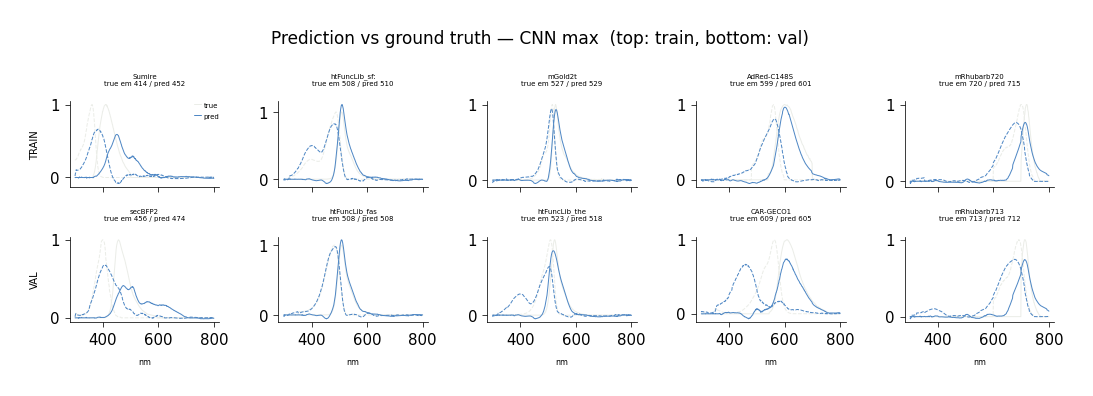

In [9]:
INSPECT = None     # None -> best-val model from the sweep; or set e.g. ("MLP","min")
K = 5

if INSPECT is None:
    a,p,_ = min(table, key=lambda x: x[2]["val"]["mse"]); INSPECT=(a,p)
arch_i, pool_i = INSPECT
net, met, cached = get_trained(arch_i, pool_i, CFG, EPOCHS)
print(f"inspecting {arch_i} {pool_i} {'(cached)' if cached else '(trained)'} | "
      f"val MSE {met['val']['mse']:.5f} | train MSE {met['train']['mse']:.5f}")

def predict_idx(idx):
    idx=np.array(idx); Hb=Ht[idx].float().to(dev)
    mask=(ar.unsqueeze(0)<torch.tensor(Ls[idx]).unsqueeze(1)).to(dev)
    net.eval()
    with torch.no_grad(): return net(Hb,mask).cpu().numpy()

def span(split,k):
    idx=m[split]; order=idx[np.argsort(EMM[idx])]
    return order[np.linspace(0,len(order)-1,k).astype(int)]

if HAVE_PLT:
    fig,axes=plt.subplots(2,K,figsize=(3*K,5),sharex=True)
    for r,split in enumerate(["train","val"]):
        sel=span(split,K); P=predict_idx(sel)
        for c,i in enumerate(sel):
            ax=axes[r,c]
            ax.plot(grid,Y[i,:G],color=apc.gray,ls="--",lw=1)
            ax.plot(grid,Y[i,G:],color=apc.gray,ls="-",lw=1,label="true")
            ax.plot(grid,P[c,:G],color=apc.aegean,ls="--",lw=1); ax.plot(grid,P[c,G:],color=apc.aegean,ls="-",lw=1,label="pred")
            te=EMM[i]; pe=grid[np.argmax(P[c,G:])]
            ax.set_title(f"{rows[i]['name'][:13]}\ntrue em {te:.0f} / pred {pe:.0f}",fontsize=7)
            if r==1: ax.set_xlabel("nm",fontsize=8)
            if c==0: ax.set_ylabel(split.upper(),fontsize=10)
    axes[0,0].legend(fontsize=7,loc="upper right")
    plt.suptitle(f"Prediction vs ground truth — {arch_i} {pool_i}  (top: train, bottom: val)")
    plt.tight_layout(); plt.show()

## 4. Learning curve (train vs val MSE per epoch)

Train the chosen model for `CURVE_EPOCHS`, logging **train and val MSE every epoch**, to diagnose
convergence. If train MSE keeps falling while val rises -> overfitting; if **both plateau high** ->
under-fitting / the signal is just hard (a different lever than regularization).

CNN max (trained) (lr=0.001, wd=0.0001, hidden=256, drop=0.2):
  best val MSE 0.02685 @ epoch 148 | final train 0.00517 / val 0.02977 | baseline 0.04926


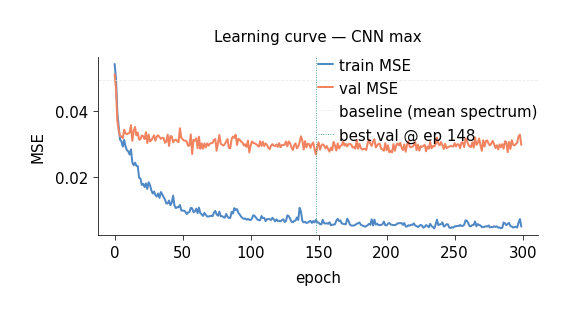

In [10]:
CURVE_CFG = None        # None -> best-val (arch,pool) from the sweep; or e.g. ("MLP","min")
CURVE_EPOCHS = 300

if CURVE_CFG is None:
    a,p,_ = min(table, key=lambda x: x[2]["val"]["mse"]); CURVE_CFG=(a,p)
ca, cp = CURVE_CFG
tr_hist, va_hist, cached = get_curve(ca, cp, CFG, CURVE_EPOCHS)
best_ep=int(np.argmin(va_hist))
print(f"{ca} {cp} {'(cached)' if cached else '(trained)'} (lr={LR}, wd={WD}, hidden={HIDDEN}, drop={DROP}):")
print(f"  best val MSE {va_hist[best_ep]:.5f} @ epoch {best_ep} | "
      f"final train {tr_hist[-1]:.5f} / val {va_hist[-1]:.5f} | baseline {base_val:.5f}")

if HAVE_PLT:
    plt.figure(figsize=(7.5,4))
    plt.plot(tr_hist, color=apc.aegean, label="train MSE"); plt.plot(va_hist, color=apc.amber, label="val MSE")
    plt.axhline(base_val, color=apc.gray, ls="--", lw=0.8, label="baseline (mean spectrum)")
    plt.axvline(best_ep, color=apc.seaweed, ls=":", lw=0.9, label=f"best val @ ep {best_ep}")
    plt.xlabel("epoch"); plt.ylabel("MSE"); plt.title(f"Learning curve — {ca} {cp}")
    plt.legend(); plt.tight_layout(); plt.show()

## Notes

- **Train vs val gap = overfitting** per config; the test split is deliberately untouched here. Pick the
  readout/architecture on **val**, then evaluate test once (separately) when you commit.
- Tune the knobs (`CONV_CH`, `KSIZE`, `HIDDEN`, `DROP`, `WD`, `EPOCHS`) to explore. min/std are cheap extra
  views of the residue distribution; max tends to capture the few decisive (chromophore) residues.